In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np



In [2]:
def bar_chart(labels, values, title, ylabel='Score', color='steelblue',
              threshold=None, output_path=None):
    fig, ax = plt.subplots(figsize=(max(6, len(labels)*1.1), 4))
    bars = ax.bar(labels, values, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    if threshold is not None:
        ax.axhline(threshold, color='tomato', linestyle='--', linewidth=1,
                   label=f'threshold {threshold:.0%}')
        ax.legend(fontsize=9)
    for bar, v in zip(bars, values):
        if v is not None and not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                    f'{v:.1%}', ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=30, ha='right', fontsize=9)
    fig.tight_layout()
    if output_path:
        plt.savefig(output_path, bbox_inches='tight', dpi=120)
    plt.show()

# Router Eval

In [ ]:
data = pd.read_csv("/Users/tracywu/Documents/Projects/Decision_System/assets/router_result.csv")
accuracy = accuracy_score(data["expected_norm"], data["predicted_mode"])
print(f"Router Avg Accuracy: {accuracy:.2f}")
print(f"Router Avg Latency: {np.mean(data["latency_ms"]):.2f}")

data["correct"] = data["expected_norm"] == data["predicted_mode"]                                             
                                            
acc_per_mode = (                                                                                                               
    data                                             
    .groupby("expected_norm")["correct"]                                                                                      
    .agg(accuracy="mean", n="count")
    .reset_index()                                                                                                                                  
    .rename(columns={"expected_norm": "mode"})            
)                                           

acc_per_mode["mode"] = ['Hybrid', "RAG", "Text2SQL"]                                                                                                                     
print(acc_per_mode)

       mode  accuracy   n
0    Hybrid  0.866667  15
1       RAG  0.958333  24
2  Text2SQL  0.952381  21


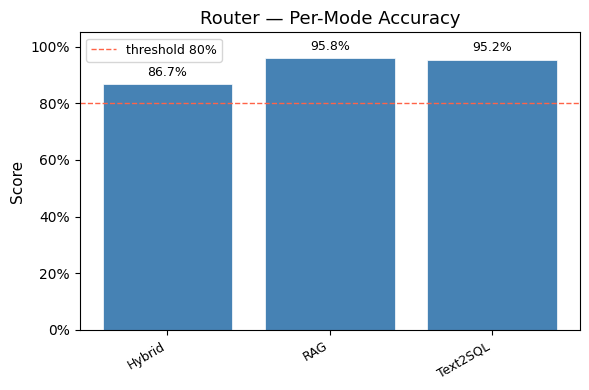

In [71]:
per_mode = (  
acc_per_mode.groupby("mode")["accuracy"]
    .mean()                                                 
)
                                                                                                                                
bar_chart(                                  
    per_mode.index.tolist(),                                                                                                   
    per_mode.values.tolist(),                             
    "Router — Per-Mode Accuracy",                                                                                              
    threshold=0.8                                                                   
)   

# Text2SQL Eval

In [54]:
sql_data = pd.read_csv("/Users/tracywu/Documents/Projects/Decision_System/assets/text2sql_result.csv")
sql_data = sql_data.replace("NA", 0)
sql_data = sql_data.fillna(0)
sql_data.head()

,id,question,expected_table,predicted_table,generated_sql,expected_result,generated_result,latency,answerable,router_mode,Databricks_result,Baseline_result
0,1,What are the sum of revenue of top 3 selling Loctite adhesives?,loctite_sales_data,loctite_sales_data,"SELECT SUM(Revenue) AS Total_Revenue FROM ( SELECT Product_Name, SUM(Revenue...",538136.25,538136.25,2796.9,True,Text2SQL,Failed,239721.51
1,2,How many Loctite products have inventory below 100 units?,loctite_inventory_tracker,loctite_inventory_tracker,SELECT COUNT(*) AS num_products_below_100_units FROM chatbot_mw.default.loct...,2,2,1765.8,True,Text2SQL,Succeeded,75
2,3,Show total sales for LOCTITE 243.,loctite_sales_data,loctite_sales_data,SELECT SUM(Revenue) AS Total_Sales FROM chatbot_mw.default.loctite_sales_dat...,107631.45,107631.45,2783.7,True,Text2SQL,Failed,107631.45
3,4,Which supplier provides LOCTITE 401?,loctite_supplier_table,loctite_supplier_table,SELECT s.Supplier_Name FROM chatbot_mw.default.loctite_supplier_table s JOIN...,Henkel Electronics Materials Asia,Henkel Electronics Materials Asia,2030.1,False,Text2SQL,Failed,0
4,5,What is the budget allocated for PRJ-001?,loctite_project_budget,loctite_project_budget,SELECT Budget_USD FROM chatbot_mw.default.loctite_project_budget WHERE Proje...,5000000,5000000,3350.6,True,Text2SQL,Failed,0


In [56]:
print(f"Text2SQL Avg Latency: {np.mean(sql_data["latency"]):.2f}")

Text2SQL Avg Latency: 2085.45


In [ ]:
total_num = len(sql_data)
databricks_acc = (sql_data["Databricks_result"]=="Succeeded").sum() / total_num
reliable_acc = (sql_data["generated_result"]==sql_data["expected_result"]).sum() / total_num
vanilla_acc = (sql_data["Baseline_result"]==sql_data["expected_result"]).sum() / total_num

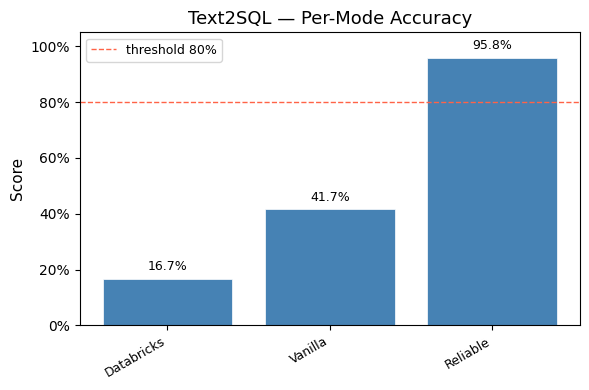

In [74]:
dict_acc = {"Databricks": databricks_acc, "Vanilla":vanilla_acc, "Reliable":reliable_acc}

bar_chart(                                  
    list(dict_acc.keys()),                                                                                                
    list(dict_acc.values()),                    
    "Text2SQL — Per-Mode Accuracy",                                                                                              
    threshold=0.8                                                                   
)   

# RAG Eval

In [58]:
df_rag = pd.read_csv("/Users/tracywu/Documents/Projects/Decision_System/assets/rag_result.csv")
df = pd.read_csv("/Users/tracywu/Documents/Projects/Decision_System/eval/dataset/rag_eval.csv")

In [ ]:
import ast

def parse_facts(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return [f.strip() for f in x.split(";") if f.strip()]
    return []

df_rag["expected_evidence_facts"] = df_rag["expected_evidence_facts"].apply(parse_facts)

# If evidence facts are stored as string like "['fact1', 'fact2']"
df_rag["expected_evidence_facts"] = df_rag["expected_evidence_facts"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

def evaluate_row(row):
    answer = row["generated_answer"]
    product = row["expected_products"]
    facts = row["expected_evidence_facts"]

    answer_lower = answer.lower()

    has_product = product.lower() in answer_lower
    has_evidence = any(f.lower() in answer_lower for f in facts)

    return pd.Series({
        "has_product": has_product,
        "has_evidence": has_evidence,
        "both_correct": has_product and has_evidence
    })

df_rag[["has_product", "has_evidence", "both_correct"]] = df_rag.apply(evaluate_row, axis=1)

In [62]:
print("Product accuracy:", df_rag["has_product"].mean())
print("Evidence recall:", df_rag["has_evidence"].mean())
print("Both correct:", df_rag["both_correct"].mean())

Product accuracy: 0.8227848101265823
Evidence recall: 0.24050632911392406
Both correct: 0.24050632911392406


In [70]:
import pandas as pd
import ast
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("BAAI/bge-base-en-v1.5")


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x)


def parse_items(x):
    if isinstance(x, list):
        return x

    if pd.isna(x):
        return []

    x = str(x).strip()

    if x.startswith("[") and x.endswith("]"):
        try:
            return [safe_str(i).strip() for i in ast.literal_eval(x)]
        except:
            pass

    return [i.strip() for i in x.split(";") if i.strip()]


def semantic_match(answer, expected_items, threshold=0.75):
    """
    Returns:
    - matched: whether any expected item is semantically matched
    - max_score: highest similarity score
    - best_match: expected item with highest score
    """
    answer = safe_str(answer)

    if not answer:
        return False, 0.0, None

    expected_items = parse_items(expected_items)

    if len(expected_items) == 0:
        return False, 0.0, None

    answer_emb = model.encode(answer, normalize_embeddings=True)
    item_embs = model.encode(expected_items, normalize_embeddings=True)

    scores = util.cos_sim(answer_emb, item_embs)[0]

    max_idx = int(scores.argmax())
    max_score = float(scores[max_idx])
    best_match = expected_items[max_idx]

    return max_score >= threshold, max_score, best_match

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8832.36it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [71]:
def evaluate_row_semantic(row):
    answer = row["generated_answer"]

    has_product, product_score, product_match = semantic_match(
        answer,
        row["expected_products"],
        threshold=0.80
    )

    has_evidence, evidence_score, evidence_match = semantic_match(
        answer,
        row["expected_evidence_facts"],
        threshold=0.75
    )

    return pd.Series({
        "has_product_semantic": has_product,
        "product_similarity": product_score,
        "matched_product": product_match,

        "has_evidence_semantic": has_evidence,
        "evidence_similarity": evidence_score,
        "matched_evidence": evidence_match,

        "both_correct_semantic": has_product and has_evidence
    })


df_rag[
    [
        "has_product_semantic",
        "product_similarity",
        "matched_product",
        "has_evidence_semantic",
        "evidence_similarity",
        "matched_evidence",
        "both_correct_semantic"
    ]
] = df_rag.apply(evaluate_row_semantic, axis=1)